# Loading Files

In [13]:
from datetime import date

today = date.today()
DATE = f'{today.month}-{today.day}-{today.year}'
DATE

'5-24-2026'

In [14]:
from pathlib import Path
import numpy as np

BASE_PATH = Path.cwd().parent / 'samples'
POSITIVE_PATH = BASE_PATH / 'positive'
NEGATIVE_PATH = BASE_PATH / 'negative'
POSITIVE_LIFECARE_PATH = BASE_PATH / 'positive-lifecare'
RESULTS_PATH = Path.cwd().parent / 'results' / DATE

paths = [BASE_PATH, POSITIVE_PATH, NEGATIVE_PATH, RESULTS_PATH]

for path in paths:
    path.mkdir(parents=True, exist_ok=True)

assert all([path.exists() for path in paths]), "path doesn't exist"

In [15]:
# Discover available samples and show counts
positives = [filepath for filepath in POSITIVE_PATH.iterdir() if filepath.suffix == '.npy']
negatives = [filepath for filepath in NEGATIVE_PATH.iterdir() if filepath.suffix == '.npy']
positives_lifecare = [filepath for filepath in POSITIVE_LIFECARE_PATH.iterdir() if filepath.suffix == '.npy']

f'{len(positives)=}, {len(negatives)=}, {len(positives_lifecare)=}'

'len(positives)=33, len(negatives)=50, len(positives_lifecare)=10'

# RAG Setup

In [16]:
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

PAPERS_DIR = Path.cwd().parent / "papers"

def _read_pdf_text(path):
    try:
        from pypdf import PdfReader
    except ImportError:
        from PyPDF2 import PdfReader
    reader = PdfReader(str(path))
    pages = []
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        pages.append((i + 1, text))
    return pages

def _chunk_text(text, size=1200, overlap=200):
    chunks = []
    start = 0
    length = len(text)
    while start < length:
        end = min(start + size, length)
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start = max(0, end - overlap)
        if end == length:
            break
    return chunks

def build_rag_index(papers_dir=PAPERS_DIR):
    docs = []
    for pdf in sorted(papers_dir.glob("*.pdf")):
        for page_num, page_text in _read_pdf_text(pdf):
            for chunk in _chunk_text(page_text):
                docs.append({"text": chunk, "source": pdf.name, "page": page_num})
    if not docs:
        return None
    vectorizer = TfidfVectorizer(stop_words="english")
    matrix = vectorizer.fit_transform([d["text"] for d in docs])
    return {"docs": docs, "vectorizer": vectorizer, "matrix": matrix}

RAG = build_rag_index()

def retrieve_context(query, k=4):
    if not RAG or not query:
        return ""
    q = RAG["vectorizer"].transform([query])
    scores = cosine_similarity(q, RAG["matrix"]).ravel()
    top_idx = scores.argsort()[::-1][:k]
    lines = []
    for idx in top_idx:
        doc = RAG["docs"][idx]
        excerpt = " ".join(doc["text"].split())
        if len(excerpt) > 400:
            excerpt = excerpt[:400] + "..."
        lines.append(f"[{doc['source']} p.{doc['page']}] {excerpt}")
    return "\n".join(lines)

# Evaluate

In [17]:
import importlib
import feature_extraction as fe
import pandas as pd
import ast

results = []

importlib.reload(fe)
with open(Path.cwd() / 'prompt.txt', 'r') as file:
    prompt = file.read()

In [18]:
LLM = 'qwen3:latest'

In [19]:
from ollama import chat

def run_samples(paths, true_label):
    for path in paths:
        print(f'=== processing {path.name} ===')
        signal = np.load(path, allow_pickle=True)
        features = fe.narrate_ecg(signal)
        rag_context = retrieve_context(features)
        user_prompt = (
            prompt
            + "\n\n[Clinical Evidence]\n"
            + (rag_context or "No relevant paper excerpts found.")
            + "\n\n[ECG Features]\n"
            + features
        )

        response = chat(
            model=LLM,
            messages=[
                {'role': 'user', 'content': user_prompt},
            ],
            options={'temperature': 0},
            think=True,
            stream=False, 
        )

        try:
            details = ast.literal_eval(response.message.content)
            # note to self: this can result in running out of memory
            result = {
                'filename': path.stem,
                'actual': true_label,
                'predicted': details['status'],
                'score': details['score'],
                'textual_response': details['textual_response'],
                'reasoning': response.message.thinking,
            }
            results.append(result)
            
        except Exception as e:
            print(f'error: {e}')
            print(f'response: {response.message.content}')
            continue

        print(response.message.content)
        print(response.message.thinking)


In [20]:
# run_samples(positives_lifecare, 'positive')

In [21]:
run_samples(negatives, 'negative')

=== processing negative_052.npy ===
{
    "status": "negative",
    "textual_response": "None of the leads V1-V3 meet the J-point elevation threshold (≥2.0mm) required for Brugada Type 1. Lead V1 shows 1.0mm J-point elevation with an ascending ST segment, Lead V2 shows 0.2mm J-point elevation with a saddleback ST segment, and Lead V3 shows J-point depression. These features do not satisfy Type 1 criteria.",
    "score": 0.1
}
Okay, let's tackle this ECG analysis for Brugada Type 1. First, I need to focus on leads V1, V2, and V3 as per the instructions. The user mentioned to ignore V4-V6, so I'll set those aside.

Starting with Lead V1: The J-point elevation is 1.0mm. Wait, the criteria say J-point needs to be ≥2.0mm for Type 1. So 1.0mm is below that threshold. That's a red flag. But maybe there's more to it. Let me check the ST segment and T wave after the J-point. The values given are a series of numbers. The ST segment here starts at 1.02 mm (which is just after the J-point) and the

In [22]:
run_samples(positives, 'positive')

=== processing positive_016.npy ===
debug
{
    "status": "positive",
    "textual_response": "Lead V1 and V2 demonstrate Brugada Type 1 morphology with J-point elevation ≥2.0mm, coved ST elevation, and inverted T waves. Corrado indices (3.09 and 2.98) exceed 1, confirming Type 1. The triangle base length in V1 (13.17mm) meets the ≥1.5mm criterion. V3 lacks sufficient J-point elevation (0.6mm) for Type 1 classification.",
    "score": 0.95
}
Okay, let's tackle this ECG analysis for Brugada Type 1. First, I need to focus on leads V1, V2, and V3 as per the instructions. The user mentioned ignoring V4-V6.

Starting with Lead V1: The J-point elevation is 5.8mm, which is well above the 2.0mm threshold. The Corrado index here is 3.09, which is greater than 1, suggesting Type 1. The triangle base length is 13.17mm, which is definitely over 1.5mm. Now, looking at the ST segment after the J-point. The values start at 5.76mm and gradually decrease: 5.81, 5.78, 5.52, etc., down to -4.66mm. This s

In [23]:
df_results = pd.DataFrame(results)
df_results

,filename,actual,predicted,score,textual_response,reasoning
0,negative_052,negative,negative,0.10,None of the leads V1-V3 meet the J-point eleva...,"Okay, let's tackle this ECG analysis for Bruga..."
1,negative_021,negative,negative,0.10,None of the V1-V3 leads demonstrate J-point el...,"Okay, let's tackle this ECG analysis for Bruga..."
2,negative_079,negative,negative,0.10,None of the leads V1-V3 meet the J-point eleva...,"Okay, let's tackle this ECG analysis for Bruga..."
3,negative_099,negative,negative,0.10,Lead V1 shows J-point elevation of 0.3mm (belo...,"Okay, let's tackle this ECG analysis for Bruga..."
4,negative_046,negative,positive,0.95,Lead V1 demonstrates J-point elevation of 3.1m...,"Okay, let's tackle this ECG analysis for Bruga..."
...,...,...,...,...,...,...
78,positive_044,positive,positive,0.95,Lead V1 demonstrates J-point elevation of 2.2m...,"Okay, let's tackle this ECG analysis for Bruga..."
79,positive_025,positive,positive,0.95,Lead V1 demonstrates J-point elevation of 2.1 ...,"Okay, let's tackle this ECG analysis for Bruga..."
80,positive_026,positive,positive,0.98,Leads V1 and V2 demonstrate Brugada Type 1 mor...,"Okay, let's tackle this query. The user wants ..."
81,positive_014,positive,positive,0.95,Lead V1 demonstrates a J-point elevation of 2....,"Okay, let's tackle this ECG analysis for Bruga..."


sensitivity: 96.97%, specificity: 94.00%, accuracy: 95.18%, auc: 97.21


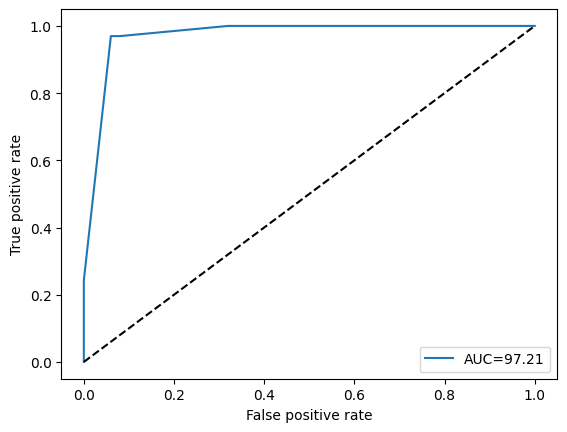

saved results to /home/elijah/CS19X-Brugada-Syndrome-Classifier/results/5-24-2026/results.csv


In [24]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

true_positives = ((df_results['actual'] == 'positive') & (df_results['predicted'] == 'positive')).sum()
true_negatives = ((df_results['actual'] == 'negative') & (df_results['predicted'] == 'negative')).sum()
false_positives = ((df_results['actual'] == 'negative') & (df_results['predicted'] == 'positive')).sum()
false_negatives = ((df_results['actual'] == 'positive') & (df_results['predicted'] == 'negative')).sum()

sensitivity = true_positives / (true_positives + false_negatives)
specificity = true_negatives / (true_negatives + false_positives) 
accuracy = (true_positives + true_negatives) / (true_positives + true_negatives + false_positives + false_negatives)

# auc-roc score
y_true = (df_results['actual'] == 'positive').astype(int)
y_score = df_results['score']
auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

print(f'sensitivity: {sensitivity*100:.2f}%, specificity: {specificity*100:.2f}%, accuracy: {accuracy*100:.2f}%, auc: {auc*100:.2f}')

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc*100:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()

df_results.to_csv(RESULTS_PATH / 'results.csv', encoding='utf-8')
print(f'saved results to {RESULTS_PATH / 'results.csv'}')
